# Experiment A - Raw xT Matrix Clustering

This notebook runs **Experiment A** for unsupervised clustering of team-season xT creation profiles.

### What this experiment studies

Each row represents one team in one season. Each team-season is described by a 192-dimensional vector:

```text
X_i = [z000, z001, ..., z191]
```

Each feature is the share of that team-season's positive created xT that starts in one pitch zone.

The tactical question is:

> Do raw xT spatial distributions naturally separate team-seasons by where they create threat?

### Why this is interpretable

The feature space maps directly back to the pitch:

```text
zone = y_bin * 16 + x_bin
grid shape = 12 rows by 16 columns
```

That means a cluster centroid can be reshaped into a pitch heatmap and interpreted as an average xT creation profile.

### Important limitation

This notebook clusters **possession threat creation locations**. It does not directly measure pressing, defensive block height, counterpressing, long-ball style, or transition speed. Cluster labels should therefore be treated as hypotheses, not final tactical truths.

## 1. Imports and Configuration

### What this cell does

This cell imports the libraries and defines the experiment settings.

### Key algorithm settings

- `GRID_L = 16`, `GRID_W = 12`, so the pitch has `16 * 12 = 192` zones.
- `K_RANGE = range(3, 11)` tests cluster counts from 3 to 10.
- `FINAL_K = 5` is the default final clustering choice.
- `PCA_VARIANCE_TARGET = 0.85` keeps enough PCA components to explain at least 85% of the variance.

### Why these settings matter

KMeans is sensitive to both feature scaling and dimensionality. This notebook therefore standardizes the 192 zone features, reduces them with PCA, evaluates multiple `k` values, and then fits the final model.

In [1]:
# --- Learning comments added by notebook-learning-commentator ---
# This setup cell defines the Experiment A contract: read the existing team-season
# clustering feature table, use the raw created_xT distribution columns, and save
# outputs to the raw baseline experiment folder.
# --- End learning comments ---

from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import pairwise_distances_argmin_min


INPUT_FILE = Path("outputs/team_season_xt_clustering_features.csv")
OUTPUT_DIR = Path("outputs/experiment_A_raw/")

EXPERIMENT_NAME = "Experiment A - Raw xT Matrix Clustering"
FEATURE_PREFIX_USED = "created_z"

GRID_L = 16
GRID_W = 12
N_ZONES = GRID_L * GRID_W

MIN_MATCH_COUNT = 5
K_RANGE = range(3, 11)
FINAL_K = 5
RANDOM_STATE = 42
PCA_VARIANCE_TARGET = 0.85

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Input file: {INPUT_FILE}")
print(f"Output folder: {OUTPUT_DIR}")
print(f"Feature prefix: {FEATURE_PREFIX_USED}")


c:\Users\Liuhy\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Liuhy\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Experiment: Experiment A - Raw xT Matrix Clustering
Input file: outputs\team_season_xt_clustering_features.csv
Output folder: outputs\experiment_A_raw
Feature prefix: created_z


## 2. Load and Validate Data

### What this cell does

This cell loads the processed team-season feature matrix and checks whether it has the expected spatial feature columns.

### Expected input shape

The input should contain:

- metadata columns such as `team_name`, `season_name`, `competition_name`, and `match_count`
- exactly 192 spatial features
- preferred feature prefix: `raw_created_z`
- fallback feature prefix: `created_z`

### Zone feature logic

The notebook expects zone features to represent the same grid convention:

```text
zone = y_bin * 16 + x_bin
z000, z001, ..., z191
```

If the features are named `created_z000` to `created_z191`, that is accepted as the fallback. Metadata is retained for interpretation, but only the 192 zone columns are used for clustering.

### What to check

Look for duplicated team-season rows, missing metadata, non-numeric feature values, or feature columns that are entirely missing. Any of these can make cluster interpretation less reliable.

In [2]:
# --- Learning comments added by notebook-learning-commentator ---
# Experiment A uses the existing processed team-season feature table.
# Only created_z000...created_z191 are kept as model features; other spatial
# channels in the same CSV are ignored so the raw baseline has a clean input.
# --- End learning comments ---

if not INPUT_FILE.exists():
    similar_files = sorted(str(path) for path in INPUT_FILE.parent.glob("*team_season*xt*"))
    similar_preview = "\n".join(similar_files[:20]) if similar_files else "No nearby team-season xT files found."
    raise FileNotFoundError(
        f"Expected input file not found: {INPUT_FILE}\n\n"
        "Experiment A should read outputs/team_season_xt_clustering_features.csv, "
        "which already contains created_z000 through created_z191.\n\n"
        f"Nearby team-season xT files found:\n{similar_preview}"
    )

raw_data = pd.read_csv(INPUT_FILE)

print(f"Dataset shape before column selection: {raw_data.shape}")
print(f"Number of rows: {len(raw_data):,}")
print(f"Number of columns: {raw_data.shape[1]:,}")

if "team_name" in raw_data.columns:
    print(f"Unique teams: {raw_data['team_name'].nunique(dropna=True):,}")
if "season_name" in raw_data.columns:
    print(f"Seasons: {raw_data['season_name'].nunique(dropna=True):,}")
elif "season_id" in raw_data.columns:
    print(f"Seasons: {raw_data['season_id'].nunique(dropna=True):,}")
if "competition_name" in raw_data.columns:
    print(f"Competitions: {raw_data['competition_name'].nunique(dropna=True):,}")
elif "competition_id" in raw_data.columns:
    print(f"Competitions: {raw_data['competition_id'].nunique(dropna=True):,}")


def zone_number_from_column(column_name, prefix=FEATURE_PREFIX_USED):
    match = re.search(rf"^{re.escape(prefix)}(\d+)$", column_name)
    if match is None:
        return None
    return int(match.group(1))


def is_zone_feature_column(column_name):
    return re.search(r"_?z\d{3}$", column_name) is not None


feature_pairs = []
for column in raw_data.columns:
    zone = zone_number_from_column(column, FEATURE_PREFIX_USED)
    if zone is not None:
        feature_pairs.append((zone, column))

if not feature_pairs:
    raise ValueError(
        "No raw created xT feature columns found. Expected columns created_z000 through created_z191."
    )

feature_pairs = sorted(feature_pairs)
feature_zone_ids = [zone for zone, _ in feature_pairs]
feature_columns = [column for _, column in feature_pairs]
metadata_columns = [column for column in raw_data.columns if not is_zone_feature_column(column)]
data = raw_data[metadata_columns + feature_columns].copy()

print(f"Feature prefix used: {FEATURE_PREFIX_USED}")
print(f"Number of feature columns found: {len(feature_columns)}")
print(f"Dataset shape after column selection: {data.shape}")

if len(feature_columns) != N_ZONES:
    raise ValueError(f"Expected exactly {N_ZONES} feature columns, found {len(feature_columns)}.")

expected_zones = list(range(N_ZONES))
if feature_zone_ids != expected_zones:
    raise ValueError(
        "Feature columns do not cover exactly z000 to z191 in order. "
        f"First detected zones: {feature_zone_ids[:10]}; last detected zones: {feature_zone_ids[-10:]}"
    )

feature_numeric = data[feature_columns].apply(pd.to_numeric, errors="coerce")
coerced_to_missing = feature_numeric.isna() & data[feature_columns].notna()
non_numeric_count = int(coerced_to_missing.sum().sum())
if non_numeric_count:
    print(f"Warning: {non_numeric_count:,} non-numeric feature values were coerced to NaN.")
data[feature_columns] = feature_numeric

all_missing_features = data[feature_columns].columns[data[feature_columns].isna().all()].tolist()
if all_missing_features:
    raise ValueError(f"These feature columns are entirely missing: {all_missing_features[:10]}")

id_duplicate_keys = ["competition_id", "season_id", "team_id"]
name_duplicate_keys = ["competition_name", "season_name", "team_name"]
if all(column in data.columns for column in id_duplicate_keys):
    duplicate_key_columns = id_duplicate_keys
elif all(column in data.columns for column in name_duplicate_keys):
    duplicate_key_columns = name_duplicate_keys
else:
    duplicate_key_columns = []

if duplicate_key_columns:
    duplicate_rows = data.duplicated(subset=duplicate_key_columns, keep=False)
    print(f"Duplicate team-season rows using {duplicate_key_columns}: {int(duplicate_rows.sum()):,}")
else:
    print("No complete team-season key was available for duplicate-row checking.")

metadata_missing = data[metadata_columns].isna().sum().sort_values(ascending=False)
metadata_missing = metadata_missing[metadata_missing > 0]
feature_missing_counts = data[feature_columns].isna().sum()

print(f"Metadata columns: {metadata_columns}")
print(f"Missing values in metadata columns: {int(metadata_missing.sum()):,}")
if not metadata_missing.empty:
    display(metadata_missing.head(20).rename("missing_values").to_frame())

print(f"Missing values in feature columns: {int(feature_missing_counts.sum()):,}")
print(f"Feature columns entirely missing: {len(all_missing_features)}")
print(f"First few feature columns: {feature_columns[:8]}")

print("Feature value summary:")
display(data[feature_columns].describe().T[["mean", "std", "min", "max"]].head(12))
display(data[metadata_columns + feature_columns[:5]].head())


Dataset shape before column selection: (922, 413)
Number of rows: 922
Number of columns: 413
Unique teams: 353
Seasons: 48
Competitions: 24
Feature prefix used: created_z
Number of feature columns found: 192
Dataset shape after column selection: (922, 221)
Duplicate team-season rows using ['competition_id', 'season_id', 'team_id']: 0
Metadata columns: ['competition_id', 'competition_name', 'country_name', 'season_id', 'season_name', 'team_id', 'team_name', 'match_count', 'move_action_count', 'pass_count', 'carry_count', 'total_net_xT', 'total_positive_xT', 'total_positive_pass_xT', 'total_positive_carry_xT', 'is_zero_positive_xT', 'below_min_matches', 'below_min_positive_xT', 'defensive_third_share', 'middle_third_share', 'attacking_third_share', 'left_side_share', 'center_share', 'right_side_share', 'left_attacking_third_share', 'center_attacking_third_share', 'right_attacking_third_share', 'pass_xT_share', 'carry_xT_share']
Missing values in metadata columns: 9


,missing_values
right_attacking_third_share,1
center_attacking_third_share,1
left_attacking_third_share,1
right_side_share,1
center_share,1
left_side_share,1
attacking_third_share,1
middle_third_share,1
defensive_third_share,1


Missing values in feature columns: 0
Feature columns entirely missing: 0
First few feature columns: ['created_z000', 'created_z001', 'created_z002', 'created_z003', 'created_z004', 'created_z005', 'created_z006', 'created_z007']
Feature value summary:


,mean,std,min,max
created_z000,0.000034,0.000089,0.0,0.000958
created_z001,0.000088,0.000157,0.0,0.001938
created_z002,0.000132,0.000336,0.0,0.009044
created_z003,0.000196,0.000270,0.0,0.003024
created_z004,0.000371,0.001061,0.0,0.019069
created_z005,0.000496,0.001112,0.0,0.020473
created_z006,0.000925,0.002754,0.0,0.054533
created_z007,0.001260,0.002701,0.0,0.042908
created_z008,0.002094,0.003956,0.0,0.057371
created_z009,0.003635,0.004837,0.0,0.064082


,competition_id,competition_name,country_name,season_id,season_name,team_id,team_name,match_count,move_action_count,pass_count,...,left_attacking_third_share,center_attacking_third_share,right_attacking_third_share,pass_xT_share,carry_xT_share,created_z000,created_z001,created_z002,created_z003,created_z004
0,2,Premier League,England,27,2015/2016,1,Arsenal,38,35479,17421,...,0.235511,0.278537,0.245525,0.744081,0.255919,0.000025,0.000044,0.000126,0.000100,0.000131
1,2,Premier League,England,27,2015/2016,22,Leicester City,38,19725,9304,...,0.259858,0.224497,0.272388,0.673307,0.326693,0.000018,0.000078,0.000092,0.000155,0.000251
2,2,Premier League,England,27,2015/2016,23,Watford,38,21633,10346,...,0.170895,0.329211,0.210860,0.682391,0.317609,0.000041,0.000089,0.000183,0.000111,0.000245
3,2,Premier League,England,27,2015/2016,24,Liverpool,38,31827,15447,...,0.205365,0.273515,0.228767,0.711488,0.288512,0.000024,0.000057,0.000093,0.000133,0.000316
4,2,Premier League,England,27,2015/2016,25,Southampton,38,25286,12189,...,0.229508,0.243894,0.251537,0.731568,0.268432,0.000025,0.000030,0.000077,0.000079,0.000140


## 3. Data Filtering

### What this cell does

This cell removes samples that are weak inputs for clustering.

### Filtering rules

1. If `match_count` exists, remove rows with fewer than `MIN_MATCH_COUNT` matches.
2. Remove rows with missing values in any of the 192 selected features.
3. Remove rows whose feature vector sums to zero.

### Formula

For each team-season `i`, the row sum is:

```text
s_i = sum_j X_ij
```

Rows with `s_i = 0` contain no usable spatial xT distribution and are removed.

### Output

The filtering audit is saved to:

```text
outputs/experiment_A_raw/filtering_report_raw.csv
```

In [3]:
# --- Learning comments added by notebook-learning-commentator ---
# This cell filters the sample before clustering.
# The main row-level formula is s_i = sum_j X_ij.
# Rows with too few matches, missing zone values, or s_i close to zero are removed.
# --- End learning comments ---

initial_row_count = len(data)
filtered = data.copy()

removed_low_match_count = 0
removed_zero_feature_sum = 0
removed_missing_features = 0

if "match_count" in filtered.columns:
    filtered["match_count"] = pd.to_numeric(filtered["match_count"], errors="coerce")
    low_match_mask = filtered["match_count"].fillna(-np.inf) < MIN_MATCH_COUNT
    removed_low_match_count = int(low_match_mask.sum())
    filtered = filtered.loc[~low_match_mask].copy()
else:
    print("Column 'match_count' not found, so the minimum-match filter is skipped.")

missing_feature_mask = filtered[feature_columns].isna().any(axis=1)
removed_missing_features = int(missing_feature_mask.sum())
filtered = filtered.loc[~missing_feature_mask].copy()

feature_sum = filtered[feature_columns].sum(axis=1)
zero_feature_mask = np.isclose(feature_sum, 0)
removed_zero_feature_sum = int(zero_feature_mask.sum())
filtered = filtered.loc[~zero_feature_mask].copy()

final_row_count = len(filtered)

filtering_report = pd.DataFrame(
    [
        {"step": "initial_rows", "row_count": initial_row_count},
        {"step": "removed_low_match_count", "row_count": removed_low_match_count},
        {"step": "removed_missing_feature_values", "row_count": removed_missing_features},
        {"step": "removed_zero_feature_sum", "row_count": removed_zero_feature_sum},
        {"step": "final_rows", "row_count": final_row_count},
    ]
)
filtering_report.to_csv(OUTPUT_DIR / "filtering_report_raw.csv", index=False)

print(f"Initial row count: {initial_row_count:,}")
print(f"Rows removed because of low match_count: {removed_low_match_count:,}")
print(f"Rows removed because of missing feature values: {removed_missing_features:,}")
print(f"Rows removed because feature sum is zero: {removed_zero_feature_sum:,}")
print(f"Final row count: {final_row_count:,}")
print(f"Saved filtering report: {OUTPUT_DIR / 'filtering_report_raw.csv'}")

if final_row_count <= FINAL_K:
    raise ValueError(
        f"Not enough filtered samples ({final_row_count}) for FINAL_K={FINAL_K}. "
        "Lower FINAL_K or relax filtering."
    )

Initial row count: 922
Rows removed because of low match_count: 633
Rows removed because of missing feature values: 0
Rows removed because feature sum is zero: 1
Final row count: 288
Saved filtering report: outputs\experiment_A_raw\filtering_report_raw.csv


## 4. Feature Matrix Preparation

### What this cell does

This cell separates the dataset into:

- `metadata_filtered`: columns used for interpretation and reporting
- `X`: the 192-column clustering feature matrix

### Core feature representation

Each row is a distribution over pitch zones:

```text
X_i = [x_i0, x_i1, ..., x_i191]
sum_j x_ij ≈ 1
```

Because the row is normalized, the clustering emphasizes **where** the team creates threat rather than **how much total xT** it creates.

### What to check

The row sums should be close to 1. If they are far from 1, the input may be a raw-volume matrix rather than a distribution matrix.

In [4]:
# --- Learning comments added by notebook-learning-commentator ---
# This cell separates metadata from the numerical feature matrix X.
# Each row of X should be a spatial distribution with sum_j X_ij approximately equal to 1.
# That makes the clustering compare spatial preference rather than total xT volume.
# --- End learning comments ---

metadata_filtered = filtered[metadata_columns].reset_index(drop=True)
X = filtered[feature_columns].reset_index(drop=True)

row_sums = X.sum(axis=1)
nonzero_row_sums = row_sums.loc[~np.isclose(row_sums, 0)]
max_abs_deviation_from_one = float((nonzero_row_sums - 1).abs().max()) if len(nonzero_row_sums) else np.nan

print(f"Feature matrix shape: {X.shape}")
print(f"Min row sum: {row_sums.min():.6f}")
print(f"Max row sum: {row_sums.max():.6f}")
print(f"Mean row sum: {row_sums.mean():.6f}")
print(f"Maximum absolute deviation from 1 for nonzero rows: {max_abs_deviation_from_one:.6f}")

if max_abs_deviation_from_one > 0.05:
    print(
        "Warning: row sums deviate from 1 by more than 0.05. "
        "Confirm that the input file is a distribution dataset."
    )

Feature matrix shape: (288, 192)
Min row sum: 1.000000
Max row sum: 1.000000
Mean row sum: 1.000000
Maximum absolute deviation from 1 for nonzero rows: 0.000000


## 5. Standardization

### What this cell does

This cell applies `StandardScaler` to the 192 zone features before PCA and KMeans.

### Formula

For each feature column `j`, StandardScaler computes:

```text
X_scaled_ij = (X_ij - mean_j) / std_j
```

### Why scaling is needed

KMeans uses Euclidean distance. Without scaling, zones with larger variance across teams can dominate the distance calculation. Standardization gives every zone a comparable scale before PCA and clustering.

In [5]:
# --- Learning comments added by notebook-learning-commentator ---
# This cell standardizes every zone feature with z = (x - mean) / std.
# KMeans is distance-based, so unscaled high-variance zones could dominate Euclidean distance.
# --- End learning comments ---

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled feature matrix shape: {X_scaled.shape}")
print(f"Mean of scaled features, average absolute value: {np.abs(X_scaled.mean(axis=0)).mean():.6f}")
print(f"Std of scaled features, average value: {X_scaled.std(axis=0).mean():.6f}")

Scaled feature matrix shape: (288, 192)
Mean of scaled features, average absolute value: 0.000000
Std of scaled features, average value: 0.994792


## 6. PCA Dimensionality Reduction

### What this cell does

This cell fits PCA to the standardized 192-zone matrix, saves the explained-variance table, and creates a lower-dimensional feature matrix for clustering.

### PCA idea

PCA finds orthogonal directions that explain the most variance:

```text
X_scaled -> PC1, PC2, ..., PCm
```

The notebook keeps the smallest number of components `m` such that:

```text
cumulative_explained_variance_m >= 0.85
```

### Why PCA helps here

Raw zone matrices can contain sparse single-zone noise. PCA compresses the matrix into broader spatial patterns before KMeans.

PCA components used: 75
Cumulative explained variance retained: 0.8527


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.110854,0.110854
1,2,0.051140,0.161995
2,3,0.044542,0.206537
3,4,0.031483,0.238020
4,5,0.022726,0.260746
5,6,0.022525,0.283271
6,7,0.018571,0.301842
7,8,0.017969,0.319812
8,9,0.017208,0.337019
9,10,0.016495,0.353514


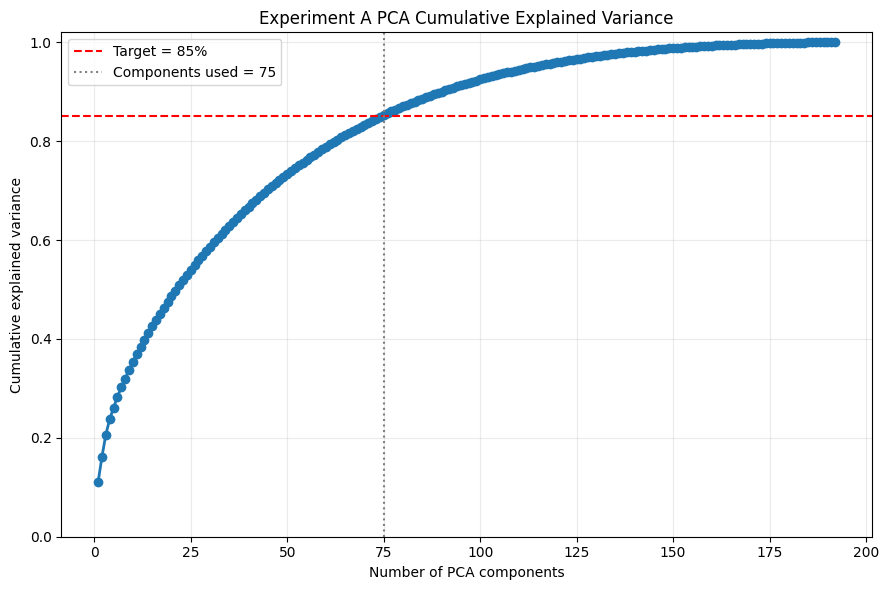

Saved PCA variance table: outputs\experiment_A_raw\pca_explained_variance_raw.csv
Saved PCA variance plot: outputs\experiment_A_raw\pca_variance_plot_raw.png


In [6]:
# --- Learning comments added by notebook-learning-commentator ---
# This cell fits PCA on X_scaled and chooses the smallest number of components
# whose cumulative explained variance reaches PCA_VARIANCE_TARGET.
# X_pca is used for clustering; X_pca_2d is only for visualization.
# --- End learning comments ---

max_pca_components = min(X_scaled.shape[0], X_scaled.shape[1])
pca_full = PCA(n_components=max_pca_components, random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_variance_table = pd.DataFrame(
    {
        "component": np.arange(1, len(explained_variance) + 1),
        "explained_variance_ratio": explained_variance,
        "cumulative_explained_variance": cumulative_variance,
    }
)
pca_variance_table.to_csv(OUTPUT_DIR / "pca_explained_variance_raw.csv", index=False)

pca_components_used = int(np.searchsorted(cumulative_variance, PCA_VARIANCE_TARGET) + 1)
pca_explained_variance_retained = float(cumulative_variance[pca_components_used - 1])

X_pca = X_pca_full[:, :pca_components_used]
if X_pca_full.shape[1] >= 2:
    X_pca_2d = X_pca_full[:, :2]
else:
    X_pca_2d = np.column_stack([X_pca_full[:, 0], np.zeros(X_pca_full.shape[0])])

print(f"PCA components used: {pca_components_used}")
print(f"Cumulative explained variance retained: {pca_explained_variance_retained:.4f}")
display(pca_variance_table.head(15))

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(
    pca_variance_table["component"],
    pca_variance_table["cumulative_explained_variance"],
    marker="o",
    linewidth=2,
)
ax.axhline(PCA_VARIANCE_TARGET, color="red", linestyle="--", label=f"Target = {PCA_VARIANCE_TARGET:.0%}")
ax.axvline(pca_components_used, color="gray", linestyle=":", label=f"Components used = {pca_components_used}")
ax.set_title("Experiment A PCA Cumulative Explained Variance")
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pca_variance_plot_raw.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved PCA variance table: {OUTPUT_DIR / 'pca_explained_variance_raw.csv'}")
print(f"Saved PCA variance plot: {OUTPUT_DIR / 'pca_variance_plot_raw.png'}")

## 7. Evaluate KMeans Cluster Numbers

### What this cell does

This cell fits KMeans for several candidate values of `k` and calculates four metrics.

### KMeans objective

KMeans assigns samples to clusters by minimizing within-cluster squared distance:

```text
min sum_i ||x_i - c_cluster(i)||^2
```

### Metrics

- `inertia`: within-cluster sum of squared distances. Lower is better, but it naturally decreases as `k` increases.
- `silhouette_score`: compares within-cluster compactness to nearest-cluster separation. Higher is better.
- `calinski_harabasz_score`: compares between-cluster dispersion to within-cluster dispersion. Higher is better.
- `davies_bouldin_score`: compares cluster similarity and spread. Lower is better.

### Interpretation caution

Do not choose `k` only from one metric. For tactical analysis, centroid heatmaps and representative team-seasons must also make sense.

c:\Users\Liuhy\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Liuhy\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Liuhy\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Liuhy\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Liuhy\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
       

,k,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score
0,3,42668.596394,0.152955,14.146315,2.206842
1,4,42349.599113,0.152326,10.181649,1.833344
2,5,40954.511246,0.029567,10.278607,2.370107
3,6,40114.595279,0.024414,9.546289,2.311838
4,7,37352.023865,0.033267,11.977131,2.019329
5,8,36518.829675,0.028666,11.375589,1.949373
6,9,36112.779278,0.023098,10.421743,2.379776
7,10,35613.277964,0.017835,9.793272,2.579320


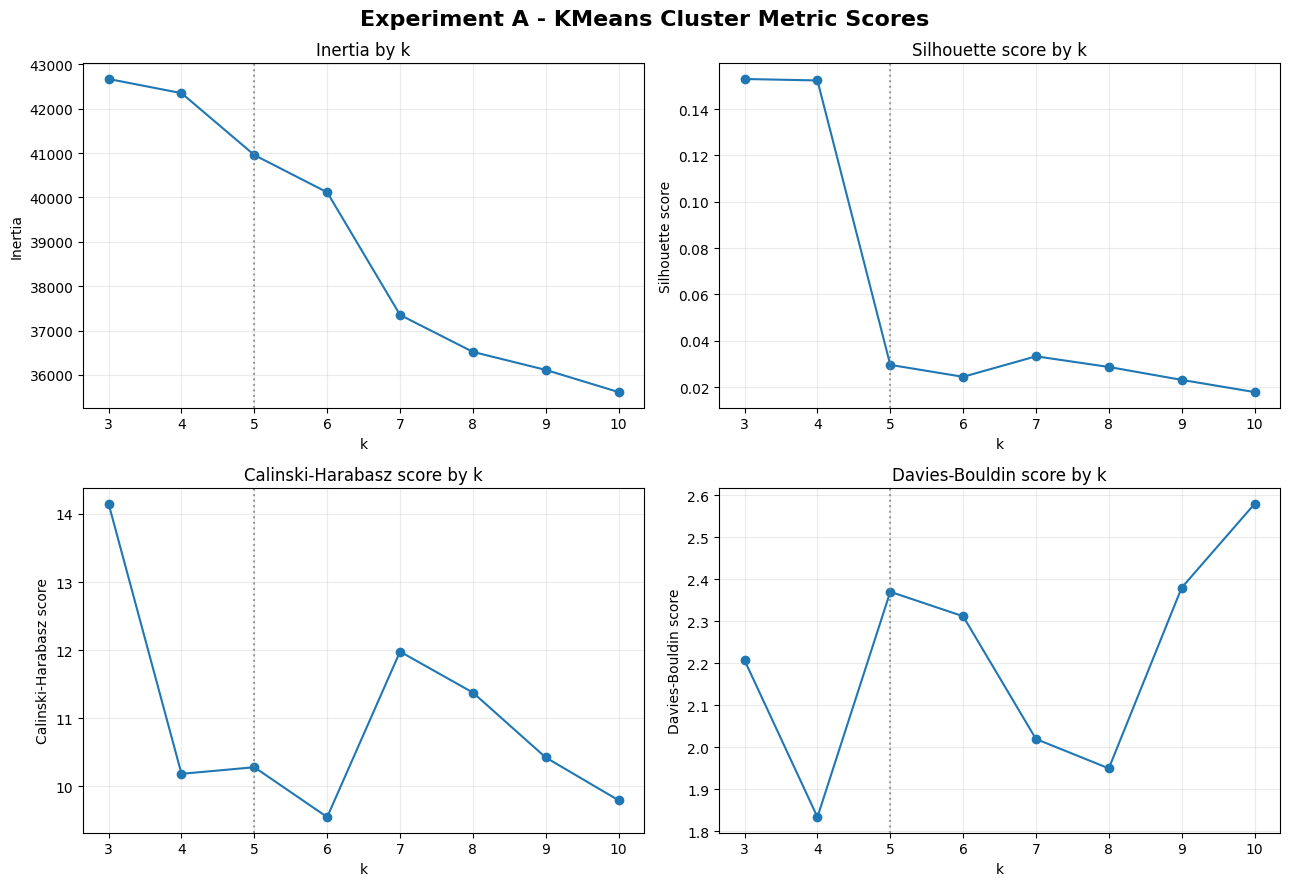

Saved cluster metric scores: outputs\experiment_A_raw\cluster_metric_scores_raw.csv
Saved cluster metric plot: outputs\experiment_A_raw\cluster_metric_scores_raw.png


In [7]:
# --- Learning comments added by notebook-learning-commentator ---
# This cell evaluates multiple KMeans cluster counts.
# KMeans minimizes inertia: sum_i ||x_i - centroid_cluster(i)||^2.
# The metrics help compare k values, but tactical interpretability still matters.
# --- End learning comments ---

def fit_kmeans_model(matrix, n_clusters):
    # Fit KMeans with modern n_init='auto', falling back for older sklearn versions.
    try:
        model = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init="auto")
        model.fit(matrix)
    except TypeError:
        model = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=20)
        model.fit(matrix)
    return model


metric_rows = []
valid_k_values = [k for k in K_RANGE if 1 < k < len(X_pca)]

if not valid_k_values:
    raise ValueError("No valid k values available. Need more filtered samples for clustering evaluation.")

skipped_k_values = [k for k in K_RANGE if k not in valid_k_values]
if skipped_k_values:
    print(f"Skipped k values because there are not enough samples: {skipped_k_values}")

for k in valid_k_values:
    model = fit_kmeans_model(X_pca, k)
    labels = model.labels_

    metric_rows.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette_score": silhouette_score(X_pca, labels),
            "calinski_harabasz_score": calinski_harabasz_score(X_pca, labels),
            "davies_bouldin_score": davies_bouldin_score(X_pca, labels),
        }
    )

cluster_metric_scores = pd.DataFrame(metric_rows)
cluster_metric_scores.to_csv(OUTPUT_DIR / "cluster_metric_scores_raw.csv", index=False)

display(cluster_metric_scores)

fig, axs = plt.subplots(2, 2, figsize=(13, 9))

axs[0, 0].plot(cluster_metric_scores["k"], cluster_metric_scores["inertia"], marker="o")
axs[0, 0].set_title("Inertia by k")
axs[0, 0].set_xlabel("k")
axs[0, 0].set_ylabel("Inertia")

axs[0, 1].plot(cluster_metric_scores["k"], cluster_metric_scores["silhouette_score"], marker="o")
axs[0, 1].set_title("Silhouette score by k")
axs[0, 1].set_xlabel("k")
axs[0, 1].set_ylabel("Silhouette score")

axs[1, 0].plot(cluster_metric_scores["k"], cluster_metric_scores["calinski_harabasz_score"], marker="o")
axs[1, 0].set_title("Calinski-Harabasz score by k")
axs[1, 0].set_xlabel("k")
axs[1, 0].set_ylabel("Calinski-Harabasz score")

axs[1, 1].plot(cluster_metric_scores["k"], cluster_metric_scores["davies_bouldin_score"], marker="o")
axs[1, 1].set_title("Davies-Bouldin score by k")
axs[1, 1].set_xlabel("k")
axs[1, 1].set_ylabel("Davies-Bouldin score")

for ax in axs.flat:
    ax.grid(alpha=0.25)
    ax.axvline(FINAL_K, color="gray", linestyle=":", alpha=0.75)

fig.suptitle("Experiment A - KMeans Cluster Metric Scores", fontsize=16, fontweight="bold")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cluster_metric_scores_raw.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved cluster metric scores: {OUTPUT_DIR / 'cluster_metric_scores_raw.csv'}")
print(f"Saved cluster metric plot: {OUTPUT_DIR / 'cluster_metric_scores_raw.png'}")

## 8. Fit Final KMeans Model

### What this cell does

This cell fits the final KMeans model using `FINAL_K` and adds the resulting cluster label to each filtered team-season.

### Output label

The cluster label column is:

```text
cluster_raw
```

### Important detail

The model is fitted in PCA space, not the original 192-dimensional feature space. Later interpretation returns to the original zone features by averaging the original distributions within each cluster.

In [8]:
# --- Learning comments added by notebook-learning-commentator ---
# This cell fits the final KMeans model in PCA space.
# The resulting integer label is stored as cluster_raw and joined back to metadata.
# --- End learning comments ---

if FINAL_K >= len(X_pca):
    raise ValueError(f"FINAL_K={FINAL_K} is not valid for {len(X_pca)} samples.")

final_kmeans = fit_kmeans_model(X_pca, FINAL_K)
cluster_raw = final_kmeans.labels_

clustered_team_seasons = filtered.reset_index(drop=True).copy()
clustered_team_seasons["cluster_raw"] = cluster_raw
clustered_team_seasons["pca_1"] = X_pca_2d[:, 0]
clustered_team_seasons["pca_2"] = X_pca_2d[:, 1]

cluster_counts = clustered_team_seasons["cluster_raw"].value_counts().sort_index()
cluster_percentages = (cluster_counts / len(clustered_team_seasons) * 100).round(2)

cluster_size_table = pd.DataFrame(
    {
        "cluster_raw": cluster_counts.index,
        "n_samples": cluster_counts.values,
        "sample_share_percent": cluster_percentages.values,
    }
)

clustered_team_seasons.to_csv(OUTPUT_DIR / "clustered_team_seasons_raw.csv", index=False)

display(cluster_size_table)
print(f"Saved clustered dataset: {OUTPUT_DIR / 'clustered_team_seasons_raw.csv'}")

c:\Users\Liuhy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,cluster_raw,n_samples,sample_share_percent
0,0,1,0.35
1,1,133,46.18
2,2,65,22.57
3,3,1,0.35
4,4,88,30.56


Saved clustered dataset: outputs\experiment_A_raw\clustered_team_seasons_raw.csv


## 9. PCA Scatter Visualization

### What this cell does

This cell plots team-seasons in the first two PCA dimensions and colors each point by `cluster_raw`.

### Why this plot is useful

The 2D scatter helps you see whether clusters are visually separated in the strongest PCA directions.

### Limitation

Only PC1 and PC2 are shown. The final KMeans model may use many PCA components, so the scatter plot is a simplified view. It should support interpretation, not replace centroid heatmaps.

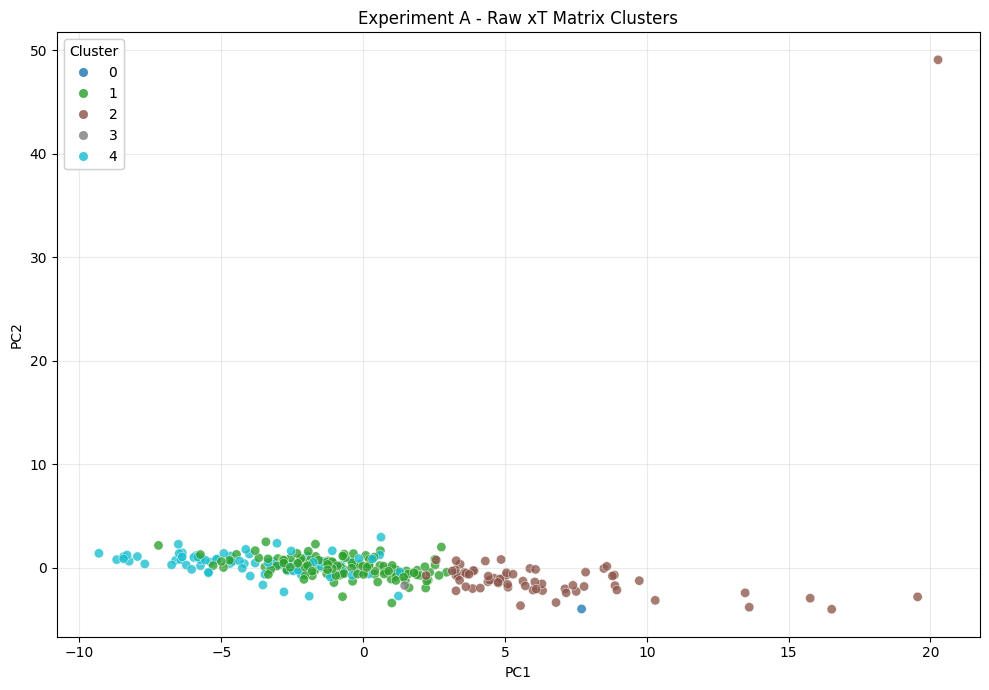

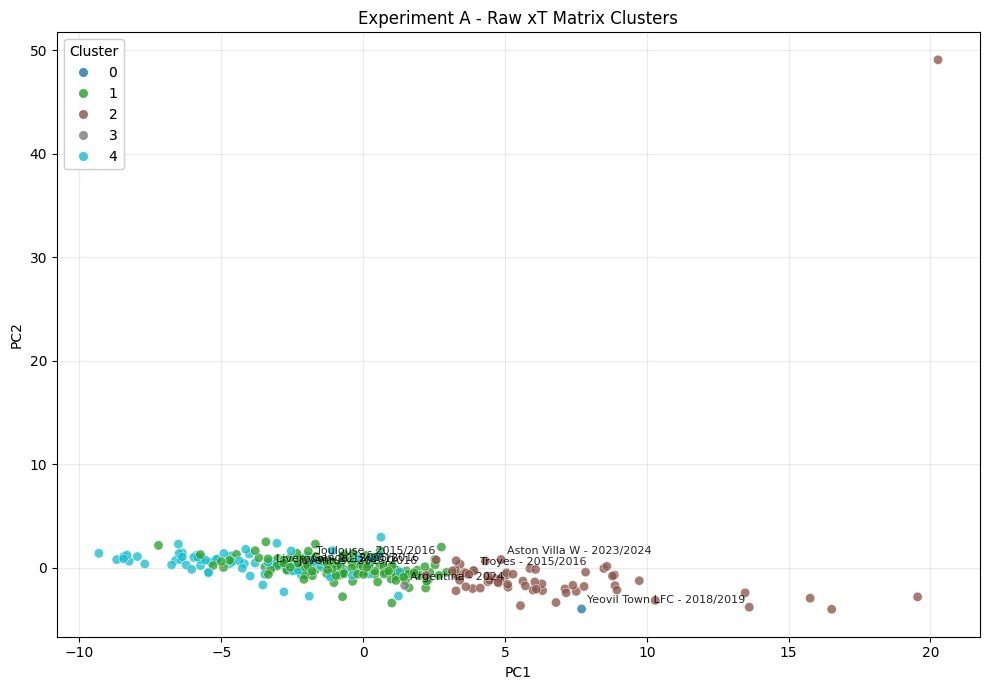

Saved PCA scatter plot: outputs\experiment_A_raw\pca_scatter_clusters_raw.png
Saved labeled PCA scatter plot: outputs\experiment_A_raw\pca_scatter_clusters_raw_labeled.png


In [9]:
# --- Learning comments added by notebook-learning-commentator ---
# This cell visualizes the clusters using PC1 and PC2.
# The labeled version annotates only representative points to avoid visual clutter.
# --- End learning comments ---

def label_for_row(row):
    parts = []
    if "team_name" in row and pd.notna(row["team_name"]):
        parts.append(str(row["team_name"]))
    if "season_name" in row and pd.notna(row["season_name"]):
        parts.append(str(row["season_name"]))
    elif "season_id" in row and pd.notna(row["season_id"]):
        parts.append(str(row["season_id"]))
    return " - ".join(parts) if parts else str(row.name)


def plot_pca_scatter(frame, output_path, label_indices=None):
    fig, ax = plt.subplots(figsize=(10, 7))
    scatter = ax.scatter(
        frame["pca_1"],
        frame["pca_2"],
        c=frame["cluster_raw"],
        cmap="tab10",
        alpha=0.78,
        s=45,
        edgecolor="white",
        linewidth=0.4,
    )
    ax.set_title("Experiment A - Raw xT Matrix Clusters")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(alpha=0.25)
    legend = ax.legend(*scatter.legend_elements(), title="Cluster", loc="best")
    ax.add_artist(legend)

    if label_indices is not None:
        for idx in label_indices:
            row = frame.loc[idx]
            ax.annotate(
                label_for_row(row),
                (row["pca_1"], row["pca_2"]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
                alpha=0.85,
            )

    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_pca_scatter(clustered_team_seasons, OUTPUT_DIR / "pca_scatter_clusters_raw.png")

assigned_centroid_indices, assigned_distances = pairwise_distances_argmin_min(X_pca, final_kmeans.cluster_centers_)
clustered_team_seasons["distance_to_centroid"] = assigned_distances

label_indices = []
for cluster_id in sorted(clustered_team_seasons["cluster_raw"].unique()):
    cluster_subset = clustered_team_seasons.loc[clustered_team_seasons["cluster_raw"] == cluster_id]
    label_indices.extend(cluster_subset.nsmallest(2, "distance_to_centroid").index.tolist())

plot_pca_scatter(
    clustered_team_seasons,
    OUTPUT_DIR / "pca_scatter_clusters_raw_labeled.png",
    label_indices=label_indices,
)

print(f"Saved PCA scatter plot: {OUTPUT_DIR / 'pca_scatter_clusters_raw.png'}")
print(f"Saved labeled PCA scatter plot: {OUTPUT_DIR / 'pca_scatter_clusters_raw_labeled.png'}")

## 10. Cluster Summary

### What this cell does

This cell creates a summary table for each cluster using available metadata and optional interpretation columns.

### Aggregation logic

For each cluster:

- count team-seasons
- calculate sample share
- list common competitions and teams
- average available numeric columns such as `match_count`, `total_positive_xT`, and spatial share features

### Why this matters

This table helps you understand whether a cluster is dominated by certain competitions, teams, eras, or broad spatial tendencies.

In [10]:
# --- Learning comments added by notebook-learning-commentator ---
# This cell summarizes each cluster with counts, shares, common categories,
# and means of any optional numeric interpretation columns that are available.
# --- End learning comments ---

def most_common_values(series, top_n=3):
    counts = series.dropna().astype(str).value_counts().head(top_n)
    if counts.empty:
        return ""
    return "; ".join(f"{name} ({count})" for name, count in counts.items())


summary_numeric_columns = [
    "match_count",
    "move_action_count",
    "total_positive_xT",
    "attacking_third_share",
    "middle_third_share",
    "defensive_third_share",
    "left_side_share",
    "center_share",
    "right_side_share",
    "pass_xT_share",
    "carry_xT_share",
]

cluster_summary_rows = []
for cluster_id, group in clustered_team_seasons.groupby("cluster_raw"):
    row = {
        "cluster_raw": cluster_id,
        "n_team_seasons": len(group),
        "share_of_total_samples": len(group) / len(clustered_team_seasons),
    }

    if "competition_name" in group.columns:
        row["most_common_competitions"] = most_common_values(group["competition_name"])
    if "team_name" in group.columns:
        row["most_common_teams"] = most_common_values(group["team_name"])

    for column in summary_numeric_columns:
        if column in group.columns:
            row[f"avg_{column}"] = pd.to_numeric(group[column], errors="coerce").mean()

    cluster_summary_rows.append(row)

cluster_summary = pd.DataFrame(cluster_summary_rows).sort_values("cluster_raw").reset_index(drop=True)
cluster_summary.to_csv(OUTPUT_DIR / "cluster_summary_raw.csv", index=False)

display(cluster_summary)
print(f"Saved cluster summary: {OUTPUT_DIR / 'cluster_summary_raw.csv'}")

,cluster_raw,n_team_seasons,share_of_total_samples,most_common_competitions,most_common_teams,avg_match_count,avg_move_action_count,avg_total_positive_xT,avg_attacking_third_share,avg_middle_third_share,avg_defensive_third_share,avg_left_side_share,avg_center_share,avg_right_side_share,avg_pass_xT_share,avg_carry_xT_share
0,0,1,0.003472,FA Women's Super League (1),Yeovil Town LFC (1),19.000000,6326.000000,6.748473,0.637314,0.310321,0.052365,0.271120,0.402017,0.326863,0.583115,0.416885
1,1,133,0.461806,FA Women's Super League (16); NWSL (16); Ligue...,Manchester City WFC (4); Chelsea FCW (4); Arse...,24.142857,16175.796992,26.603055,0.727800,0.248072,0.024128,0.294014,0.327390,0.378597,0.685786,0.314214
2,2,65,0.225694,FA Women's Super League (28); Frauen Bundeslig...,Brighton & Hove Albion WFC (4); Everton LFC (4...,20.415385,11624.415385,15.230642,0.683962,0.274018,0.042021,0.281376,0.323852,0.394771,0.649156,0.350844
3,3,1,0.003472,Copa America (1),Argentina (1),6.000000,5415.000000,6.458334,0.697359,0.260615,0.042026,0.191440,0.391564,0.416995,0.665562,0.334438
4,4,88,0.305556,La Liga (23); FIFA World Cup (14); Premier Lea...,Barcelona (17); England (4); Paris Saint-Germa...,23.011364,21561.340909,32.837310,0.700401,0.278819,0.020780,0.279418,0.389284,0.331298,0.707836,0.292164


Saved cluster summary: outputs\experiment_A_raw\cluster_summary_raw.csv


## 11. Cluster Centroid Analysis

### What this cell does

This cell computes cluster centroids in the original 192-dimensional xT distribution space.

### Formula

For cluster `k`, the original-space centroid is:

```text
centroid_kj = mean(X_ij for all samples i assigned to cluster k)
```

where `j` is one of the 192 pitch zones.

### Why this is the main interpretation step

The KMeans model is fitted in PCA space, but a pitch heatmap is easier to interpret in football terms. The centroid heatmaps show the average zone-level xT creation profile for each cluster.

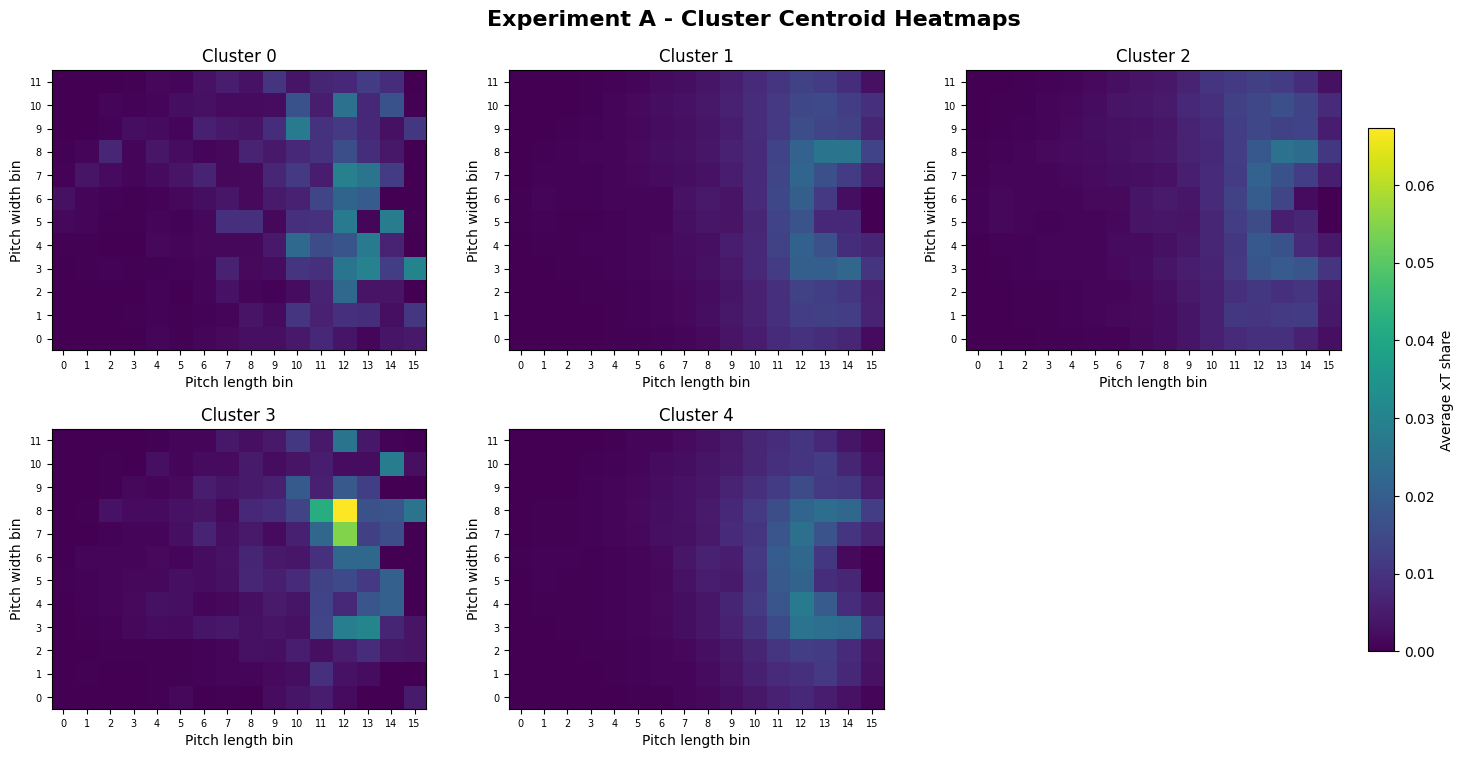

Saved cluster centroid vectors: outputs\experiment_A_raw\cluster_centroids_raw.csv
Saved cluster centroid heatmaps: outputs\experiment_A_raw\cluster_centroid_heatmaps_raw.png


In [11]:
# --- Learning comments added by notebook-learning-commentator ---
# This cell interprets clusters in the original 192-zone feature space.
# For each cluster, centroid_j = mean of original unscaled feature j among cluster members.
# The centroid vector is reshaped to a 12 by 16 grid for pitch heatmaps.
# --- End learning comments ---

cluster_centroids_raw = (
    clustered_team_seasons.groupby("cluster_raw")[feature_columns]
    .mean()
    .sort_index()
)
cluster_centroids_raw.to_csv(OUTPUT_DIR / "cluster_centroids_raw.csv")

centroid_grids = {
    cluster_id: row.values.reshape(GRID_W, GRID_L)
    for cluster_id, row in cluster_centroids_raw.iterrows()
}

vmax = max(float(grid.max()) for grid in centroid_grids.values())
vmin = 0.0

n_clusters = len(cluster_centroids_raw)
ncols = min(3, n_clusters)
nrows = math.ceil(n_clusters / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5.2 * ncols, 3.8 * nrows))
axes = np.asarray(axes).reshape(-1)

for ax, (cluster_id, grid) in zip(axes, centroid_grids.items()):
    image = ax.imshow(grid, origin="lower", aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_xlabel("Pitch length bin")
    ax.set_ylabel("Pitch width bin")
    ax.set_xticks(range(GRID_L))
    ax.set_yticks(range(GRID_W))
    ax.tick_params(labelsize=7)

for ax in axes[len(centroid_grids):]:
    ax.axis("off")

fig.suptitle("Experiment A - Cluster Centroid Heatmaps", fontsize=16, fontweight="bold")
fig.subplots_adjust(left=0.05, right=0.92, bottom=0.06, top=0.90, wspace=0.22, hspace=0.28)
fig.colorbar(
    image,
    ax=axes[:len(centroid_grids)],
    shrink=0.82,
    pad=0.02,
    fraction=0.03,
    label="Average xT share",
)
fig.savefig(OUTPUT_DIR / "cluster_centroid_heatmaps_raw.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved cluster centroid vectors: {OUTPUT_DIR / 'cluster_centroids_raw.csv'}")
print(f"Saved cluster centroid heatmaps: {OUTPUT_DIR / 'cluster_centroid_heatmaps_raw.png'}")

## 12. Top Zones Per Cluster

### What this cell does

This cell identifies the 10 highest-value zones in each cluster centroid.

### Formula

For each cluster centroid vector:

```text
top zones = argsort(centroid values, descending)[:10]
```

Each selected zone is converted back into:

```text
x_bin = zone % 16
y_bin = zone // 16
```

### Why this helps

Top zones provide a compact numeric summary of each centroid heatmap.

In [12]:
# --- Learning comments added by notebook-learning-commentator ---
# This cell ranks each cluster centroid's zones from highest to lowest average xT share.
# It converts zone id back to grid coordinates with x_bin = zone % 16 and y_bin = zone // 16.
# --- End learning comments ---

top_zone_rows = []

for cluster_id, centroid in cluster_centroids_raw.iterrows():
    top_columns = centroid.sort_values(ascending=False).head(10)
    for rank, (column, value) in enumerate(top_columns.items(), start=1):
        zone = zone_number_from_column(column, FEATURE_PREFIX_USED)
        top_zone_rows.append(
            {
                "cluster_raw": cluster_id,
                "rank": rank,
                "zone": zone,
                "x_bin": zone % GRID_L,
                "y_bin": zone // GRID_L,
                "centroid_value": value,
            }
        )

cluster_top_zones = pd.DataFrame(top_zone_rows)
cluster_top_zones.to_csv(OUTPUT_DIR / "cluster_top_zones_raw.csv", index=False)

display(cluster_top_zones)
print(f"Saved cluster top zones: {OUTPUT_DIR / 'cluster_top_zones_raw.csv'}")

,cluster_raw,rank,zone,x_bin,y_bin,centroid_value
0,0,1,63,15,3,0.030292
1,0,2,61,13,3,0.029906
2,0,3,124,12,7,0.029333
3,0,4,94,14,5,0.028549
4,0,5,77,13,4,0.028060
5,0,6,154,10,9,0.027995
6,0,7,92,12,5,0.027740
7,0,8,60,12,3,0.026254
8,0,9,125,13,7,0.025877
9,0,10,172,12,10,0.025280


Saved cluster top zones: outputs\experiment_A_raw\cluster_top_zones_raw.csv


## 13. Representative Team-Seasons

### What this cell does

This cell finds the five team-seasons closest to each cluster centroid in PCA clustering space.

### Formula

Distance is Euclidean distance in PCA space:

```text
distance_i = ||X_pca_i - centroid_pca_cluster(i)||
```

### Interpretation

Representative team-seasons are examples that sit near the cluster center. They are useful for naming clusters, but they are not ground-truth tactical labels.

In [13]:
# --- Learning comments added by notebook-learning-commentator ---
# This cell finds representative team-seasons nearest to each cluster centroid.
# Distance is Euclidean distance in PCA space: ||sample - assigned_centroid||.
# --- End learning comments ---

representative_columns = [
    "cluster_raw",
    "team_name",
    "season_name",
    "competition_name",
    "distance_to_centroid",
    "total_positive_xT",
    "match_count",
    "move_action_count",
]
available_representative_columns = [
    column for column in representative_columns if column in clustered_team_seasons.columns
]

representatives = (
    clustered_team_seasons.sort_values(["cluster_raw", "distance_to_centroid"])
    .groupby("cluster_raw", as_index=False)
    .head(5)
    .loc[:, available_representative_columns]
    .reset_index(drop=True)
)

representatives.to_csv(OUTPUT_DIR / "cluster_representatives_raw.csv", index=False)

display(representatives)
print(f"Saved representative team-seasons: {OUTPUT_DIR / 'cluster_representatives_raw.csv'}")

,cluster_raw,team_name,season_name,competition_name,distance_to_centroid,total_positive_xT,match_count,move_action_count
0,0,Yeovil Town LFC,2018/2019,FA Women's Super League,0.000000e+00,6.748473,19,6326
1,1,Genoa,2015/2016,Serie A,4.314455e+00,44.087216,38,25613
2,1,Toulouse,2015/2016,Ligue 1,5.082842e+00,36.821253,38,23943
3,1,Inter Milan,2015/2016,Serie A,5.116306e+00,48.394571,38,30961
4,1,Southampton,2015/2016,Premier League,5.369911e+00,45.815391,38,25286
5,1,Chievo,2015/2016,Serie A,5.382909e+00,32.614265,38,22806
6,2,Aston Villa W,2023/2024,FA Women's Super League,7.528664e+00,23.758985,22,17794
7,2,Troyes,2015/2016,Ligue 1,7.803479e+00,33.526339,37,25836
8,2,Athletic Club Bilbao,2023/2024,Liga F,8.156760e+00,27.314730,30,22397
9,2,Real Sociedad de F?tbol,2023/2024,Liga F,8.431111e+00,27.676447,30,23133


Saved representative team-seasons: outputs\experiment_A_raw\cluster_representatives_raw.csv


## 14. Cluster Naming Support Table

### What this cell does

This cell creates a table designed to help manually name clusters.

### Logic

For each cluster, the table includes:

- top three centroid zones
- broad third shares: defensive, middle, attacking
- width shares: left, center, right
- representative team examples
- a neutral tentative description

### Naming caution

The tentative description is based only on xT creation locations. Avoid labels like "pressing", "counterattack", or "long-ball" unless later feature sets directly measure those behaviors.

In [14]:
# --- Learning comments added by notebook-learning-commentator ---
# This cell builds neutral naming support from centroid-derived thirds, width channels,
# top zones, and representative examples. It avoids overclaiming tactical labels.
# --- End learning comments ---

left_zone_columns = [
    column for column in feature_columns
    if (zone_number_from_column(column, FEATURE_PREFIX_USED) // GRID_L) in range(0, 4)
]
center_zone_columns = [
    column for column in feature_columns
    if (zone_number_from_column(column, FEATURE_PREFIX_USED) // GRID_L) in range(4, 8)
]
right_zone_columns = [
    column for column in feature_columns
    if (zone_number_from_column(column, FEATURE_PREFIX_USED) // GRID_L) in range(8, 12)
]
defensive_third_columns = [
    column for column in feature_columns
    if (zone_number_from_column(column, FEATURE_PREFIX_USED) % GRID_L) in range(0, 5)
]
middle_third_columns = [
    column for column in feature_columns
    if (zone_number_from_column(column, FEATURE_PREFIX_USED) % GRID_L) in range(5, 11)
]
attacking_third_columns = [
    column for column in feature_columns
    if (zone_number_from_column(column, FEATURE_PREFIX_USED) % GRID_L) in range(11, 16)
]


def centroid_share(row, columns):
    return float(row[columns].sum())


def neutral_description(row):
    attacking = row.get("attacking_third_share", np.nan)
    middle = row.get("middle_third_share", np.nan)
    defensive = row.get("defensive_third_share", np.nan)
    left = row.get("left_side_share", np.nan)
    center = row.get("center_share", np.nan)
    right = row.get("right_side_share", np.nan)

    if pd.notna(attacking) and attacking > max(middle, defensive) + 0.05:
        return "High attacking-third xT concentration"
    if pd.notna(defensive) and defensive > max(middle, attacking) + 0.05:
        return "Deep-origin xT creation profile"
    if pd.notna(center) and center > max(left, right) + 0.05:
        return "Central xT creation profile"
    if pd.notna(left) and pd.notna(right) and max(left, right) > center + 0.05:
        return "Wide-side xT creation profile"
    return "Balanced xT creation distribution"


naming_rows = []

for cluster_id, centroid in cluster_centroids_raw.iterrows():
    top_three = centroid.sort_values(ascending=False).head(3)
    top_zones = [
        (zone_number_from_column(column, FEATURE_PREFIX_USED), value)
        for column, value in top_three.items()
    ]

    row = {
        "cluster_raw": cluster_id,
        "n_team_seasons": int(cluster_counts.loc[cluster_id]),
        "top_zone_1": top_zones[0][0],
        "top_zone_1_share": top_zones[0][1],
        "top_zone_2": top_zones[1][0],
        "top_zone_2_share": top_zones[1][1],
        "top_zone_3": top_zones[2][0],
        "top_zone_3_share": top_zones[2][1],
        "attacking_third_share": centroid_share(centroid, attacking_third_columns),
        "middle_third_share": centroid_share(centroid, middle_third_columns),
        "defensive_third_share": centroid_share(centroid, defensive_third_columns),
        "left_side_share": centroid_share(centroid, left_zone_columns),
        "center_share": centroid_share(centroid, center_zone_columns),
        "right_side_share": centroid_share(centroid, right_zone_columns),
    }

    cluster_reps = representatives.loc[representatives["cluster_raw"] == cluster_id].head(3)
    if "team_name" in cluster_reps.columns:
        if "season_name" in cluster_reps.columns:
            row["example_representative_teams"] = "; ".join(
                f"{team} ({season})"
                for team, season in zip(cluster_reps["team_name"], cluster_reps["season_name"])
            )
        else:
            row["example_representative_teams"] = "; ".join(cluster_reps["team_name"].astype(str))
    else:
        row["example_representative_teams"] = ""

    row["tentative_description"] = neutral_description(row)
    naming_rows.append(row)

cluster_naming_support = pd.DataFrame(naming_rows)
ordered_naming_columns = [
    "cluster_raw",
    "n_team_seasons",
    "tentative_description",
    "top_zone_1",
    "top_zone_1_share",
    "top_zone_2",
    "top_zone_2_share",
    "top_zone_3",
    "top_zone_3_share",
    "attacking_third_share",
    "middle_third_share",
    "defensive_third_share",
    "left_side_share",
    "center_share",
    "right_side_share",
    "example_representative_teams",
]
cluster_naming_support = cluster_naming_support[ordered_naming_columns]
cluster_naming_support.to_csv(OUTPUT_DIR / "cluster_naming_support_raw.csv", index=False)

display(cluster_naming_support)
print(f"Saved cluster naming support table: {OUTPUT_DIR / 'cluster_naming_support_raw.csv'}")

,cluster_raw,n_team_seasons,tentative_description,top_zone_1,top_zone_1_share,top_zone_2,top_zone_2_share,top_zone_3,top_zone_3_share,attacking_third_share,middle_third_share,defensive_third_share,left_side_share,center_share,right_side_share,example_representative_teams
0,0,1,High attacking-third xT concentration,63,0.030292,61,0.029906,124,0.029333,0.637314,0.310321,0.052365,0.271120,0.402017,0.326863,Yeovil Town LFC (2018/2019)
1,1,133,High attacking-third xT concentration,142,0.026017,141,0.025897,62,0.022244,0.727800,0.248072,0.024128,0.294014,0.327390,0.378597,Genoa (2015/2016); Toulouse (2015/2016); Inter...
2,2,65,High attacking-third xT concentration,141,0.025157,142,0.023923,124,0.021252,0.683962,0.274018,0.042021,0.281376,0.323852,0.394771,Aston Villa W (2023/2024); Troyes (2015/2016);...
3,3,1,High attacking-third xT concentration,140,0.067328,124,0.054638,139,0.041821,0.697359,0.260615,0.042026,0.191440,0.391564,0.416995,Argentina (2024)
4,4,88,High attacking-third xT concentration,76,0.027453,60,0.025622,124,0.024806,0.700401,0.278819,0.020780,0.279418,0.389284,0.331298,Juventus (2015/2016); Liverpool (2015/2016); R...


Saved cluster naming support table: outputs\experiment_A_raw\cluster_naming_support_raw.csv


## 15. Experiment Summary

### What this cell does

This cell saves a one-row summary of the experiment configuration and final clustering metrics.

### Why this matters

Experiment A is a baseline. This table makes it easier to compare against Experiment B and Experiment C using the same fields:

- number of samples
- number of features
- final `k`
- PCA components retained
- final clustering metrics
- feature prefix used

In [15]:
# --- Learning comments added by notebook-learning-commentator ---
# This cell saves a one-row record of the final experiment settings and metrics.
# It is designed for comparing Experiment A against later clustering experiments.
# --- End learning comments ---

final_silhouette = silhouette_score(X_pca, cluster_raw)
final_calinski_harabasz = calinski_harabasz_score(X_pca, cluster_raw)
final_davies_bouldin = davies_bouldin_score(X_pca, cluster_raw)

experiment_summary = pd.DataFrame(
    [
        {
            "experiment_name": EXPERIMENT_NAME,
            "input_file": str(INPUT_FILE),
            "output_folder": str(OUTPUT_DIR),
            "number_of_samples": len(clustered_team_seasons),
            "number_of_features": len(feature_columns),
            "final_k": FINAL_K,
            "pca_components_used": pca_components_used,
            "pca_explained_variance_retained": pca_explained_variance_retained,
            "final_silhouette_score": final_silhouette,
            "final_calinski_harabasz_score": final_calinski_harabasz,
            "final_davies_bouldin_score": final_davies_bouldin,
            "feature_prefix_used": FEATURE_PREFIX_USED,
        }
    ]
)
experiment_summary.to_csv(OUTPUT_DIR / "experiment_summary_raw.csv", index=False)

display(experiment_summary)
print(f"Saved experiment summary: {OUTPUT_DIR / 'experiment_summary_raw.csv'}")

,experiment_name,input_file,output_folder,number_of_samples,number_of_features,final_k,pca_components_used,pca_explained_variance_retained,final_silhouette_score,final_calinski_harabasz_score,final_davies_bouldin_score,feature_prefix_used
0,Experiment A - Raw xT Matrix Clustering,outputs\team_season_xt_clustering_features.csv,outputs\experiment_A_raw,288,192,5,75,0.852683,0.029567,10.278607,2.370107,created_z


Saved experiment summary: outputs\experiment_A_raw\experiment_summary_raw.csv


## Experiment A Interpretation Notes

Raw xT matrix clustering captures where team-seasons create positive possession threat across the pitch.

### What it captures well

- Spatial preference in xT creation.
- Broad differences between teams that create threat from deep, central, wide, or advanced zones.
- Interpretable centroid profiles because each feature maps to a pitch zone.

### What it may miss

- Defensive structure.
- Pressing or counterpressing.
- Transition speed.
- Match-state effects.
- Sequence context before or after the action.
- Match-to-match variation inside one season.

### Why centroid heatmaps matter most

The PCA scatter plot shows separation in two dimensions, but centroid heatmaps return clusters to the original pitch grid. That makes them the main tool for tactical interpretation.

### How to use the results

Treat clusters as hypotheses. A good cluster name should be supported by:

- centroid heatmaps
- top zones
- representative team-seasons
- cluster summary statistics

### Next experiment comparisons

- **Experiment B** should test whether smoothing reduces single-zone noise.
- **Experiment C** should test whether multi-channel features provide richer tactical interpretation than raw xT distribution alone.